  district  avg_soc
0   Akatsi   2.1375
1   Tamale   0.9000
2   Kumasi   1.9250
3   Nsawam   2.1000
4    Ejura   1.3900


C:\Users\Denis\AppData\Local\Temp\ipykernel_35864\842120157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='district', y='avg_soc', palette='viridis')


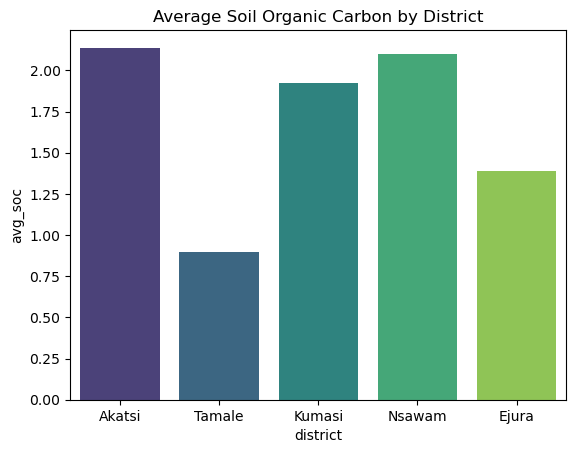

In [9]:
# Step 1: Import your hammer
from db_config import run_query

# Step 2: Query the database
df = run_query("SELECT district, AVG(soc_percent) AS avg_soc FROM soil_samples GROUP BY district;")

# Step 3: Look at the data
print(df)

# Step 4: Save it if you need to
df.to_csv("outputs/avg_soc_samples.csv", index=False)

# Step 5: (Optional) Make a chart
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=df, x='district', y='avg_soc', palette='viridis')
plt.title("Average Soil Organic Carbon by District")
plt.savefig("figures/avg_soc_barplot.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from db_config import run_query
import numpy as np

# --- Get the data two ways ---
df = run_query("SELECT district, AVG(soc_percent) AS avg_soc FROM soil_samples GROUP BY district;")
df_second = run_query("SELECT * FROM soil_samples;")
grouped_df = df_second.groupby('district')['soc_percent'].mean()

# --- Make both tables look identical ---
grouped_df = grouped_df.reset_index()
grouped_df = grouped_df.rename(columns={'soc_percent': 'avg_soc'})
df = df.sort_values('district').reset_index(drop=True)
grouped_df = grouped_df.sort_values('district').reset_index(drop=True)
df['avg_soc'] = df['avg_soc'].astype(float)
grouped_df['avg_soc'] = grouped_df['avg_soc'].astype(float)

# --- Compare ---
df_r = df.round(4)
grouped_r = grouped_df.round(4)

if df_r.equals(grouped_r):
    print("✅ SQL and pandas agree — same districts, same averages.")
else:
    print("❌ They differ. Here's exactly where:")
    merged = df.merge(grouped_df, on='district', suffixes=('_sql', '_pandas'))
    mismatch = merged[~np.isclose(merged['avg_soc_sql'], merged['avg_soc_pandas'])]
    print(mismatch)
    print("np.allclose check:", np.allclose(df['avg_soc'], grouped_df['avg_soc']))

✅ SQL and pandas agree — same districts, same averages.
